In [1]:
from ultralytics import YOLO
import shutil
import os
import matplotlib.pyplot as plt
import cv2
import pandas as pd
import yaml
from IPython.display import Image, display
from roboflow import Roboflow

In [2]:
rf = Roboflow(api_key="B6S1UWw3tkVY7061vg9U")
project = rf.workspace("footbaldetection-tiny4").project("finalv2")
version = project.version(1)
dataset = version.download("yolo11")

loading Roboflow workspace...
loading Roboflow project...

Version export complete for yolo11 format


In [3]:
# model_n = YOLO("yolo11n.pt")
model_x = YOLO("yolo11x.pt")

In [4]:
# train_results = model_n.train(
train_results = model_x.train(
    data="FinalV2-1/data.yaml",  # path to dataset YAML
    epochs=80,  # number of training epochs
    hsv_s=0.5,
    hsv_v=0.5,
    translate=0.1,
    scale=0.6,
    perspective=0.0005,
    shear=40,
    fliplr=0.5,
    exist_ok=True)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3090, 24117MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=FinalV2-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=

In [ ]:
# results = model_n.predict(
results = model_x.predict(
    source="FinalV2-1/test/images",
    conf=0.5,
    iou=0.5,
    save=True,
    project="modelos_yolo11x/",
    name="predicciones_test",
    exist_ok=True,
)


image 1/288 /home/jiteich/repos/ceia/vision_computadora_ii/TP_VpC2/FinalV2-1/test/images/100_PNG.rf.62515d18bcdd77f10fd85595b189d664.jpg: 640x640 1 ball, 9 players, 2.3ms
image 2/288 /home/jiteich/repos/ceia/vision_computadora_ii/TP_VpC2/FinalV2-1/test/images/10_PNG.rf.0d778e176cc02a67735398924e800e9c.jpg: 640x640 1 ball, 1 goalkeeper, 6 players, 1 referee, 2.2ms
image 3/288 /home/jiteich/repos/ceia/vision_computadora_ii/TP_VpC2/FinalV2-1/test/images/111_PNG.rf.2be3c370d8cafb2319c9f5c06d6cf4d7.jpg: 640x640 2 balls, 9 players, 2.2ms
image 4/288 /home/jiteich/repos/ceia/vision_computadora_ii/TP_VpC2/FinalV2-1/test/images/131_PNG.rf.34ddd0db1dfd39c58c918ec293d485e9.jpg: 640x640 1 ball, 6 players, 1 referee, 2.1ms
image 5/288 /home/jiteich/repos/ceia/vision_computadora_ii/TP_VpC2/FinalV2-1/test/images/136_PNG.rf.51273fec87846bbdb6f3726ca3ab843e.jpg: 640x640 1 ball, 5 players, 2.0ms
image 6/288 /home/jiteich/repos/ceia/vision_computadora_ii/TP_VpC2/FinalV2-1/test/images/149_PNG.rf.0776b19a

In [ ]:
# Guardo en yolo11x/ el .pt, el results.csv y los gráficos del train/
files_to_save = [
    "runs/detect/train/weights/best.pt", 
    "runs/detect/train/results/results.csv",
    "runs/detect/train/results/results.png",
    "runs/detect/train/results/BoxPR_curve.png",
    "runs/detect/train/results/BoxP_curve.png",
    "runs/detect/train/results/BoxR_curve.png",
    "runs/detect/train/results/BoxF1_curve.png",
    "runs/detect/train/results/confusion_matrix.png",
    "runs/detect/train/results/confusion_matrix_normalized.png",
]
os.makedirs("yolo11x", exist_ok=True)
for file in files_to_save:
    destino = f"yolo11x/{file.split("/")[-1]}"
    shutil.copy(file, destino)
# origen = "runs/detect/train/weights/best.pt"
# destino = "yolo11x_best.pt"



Mostrando: results.png


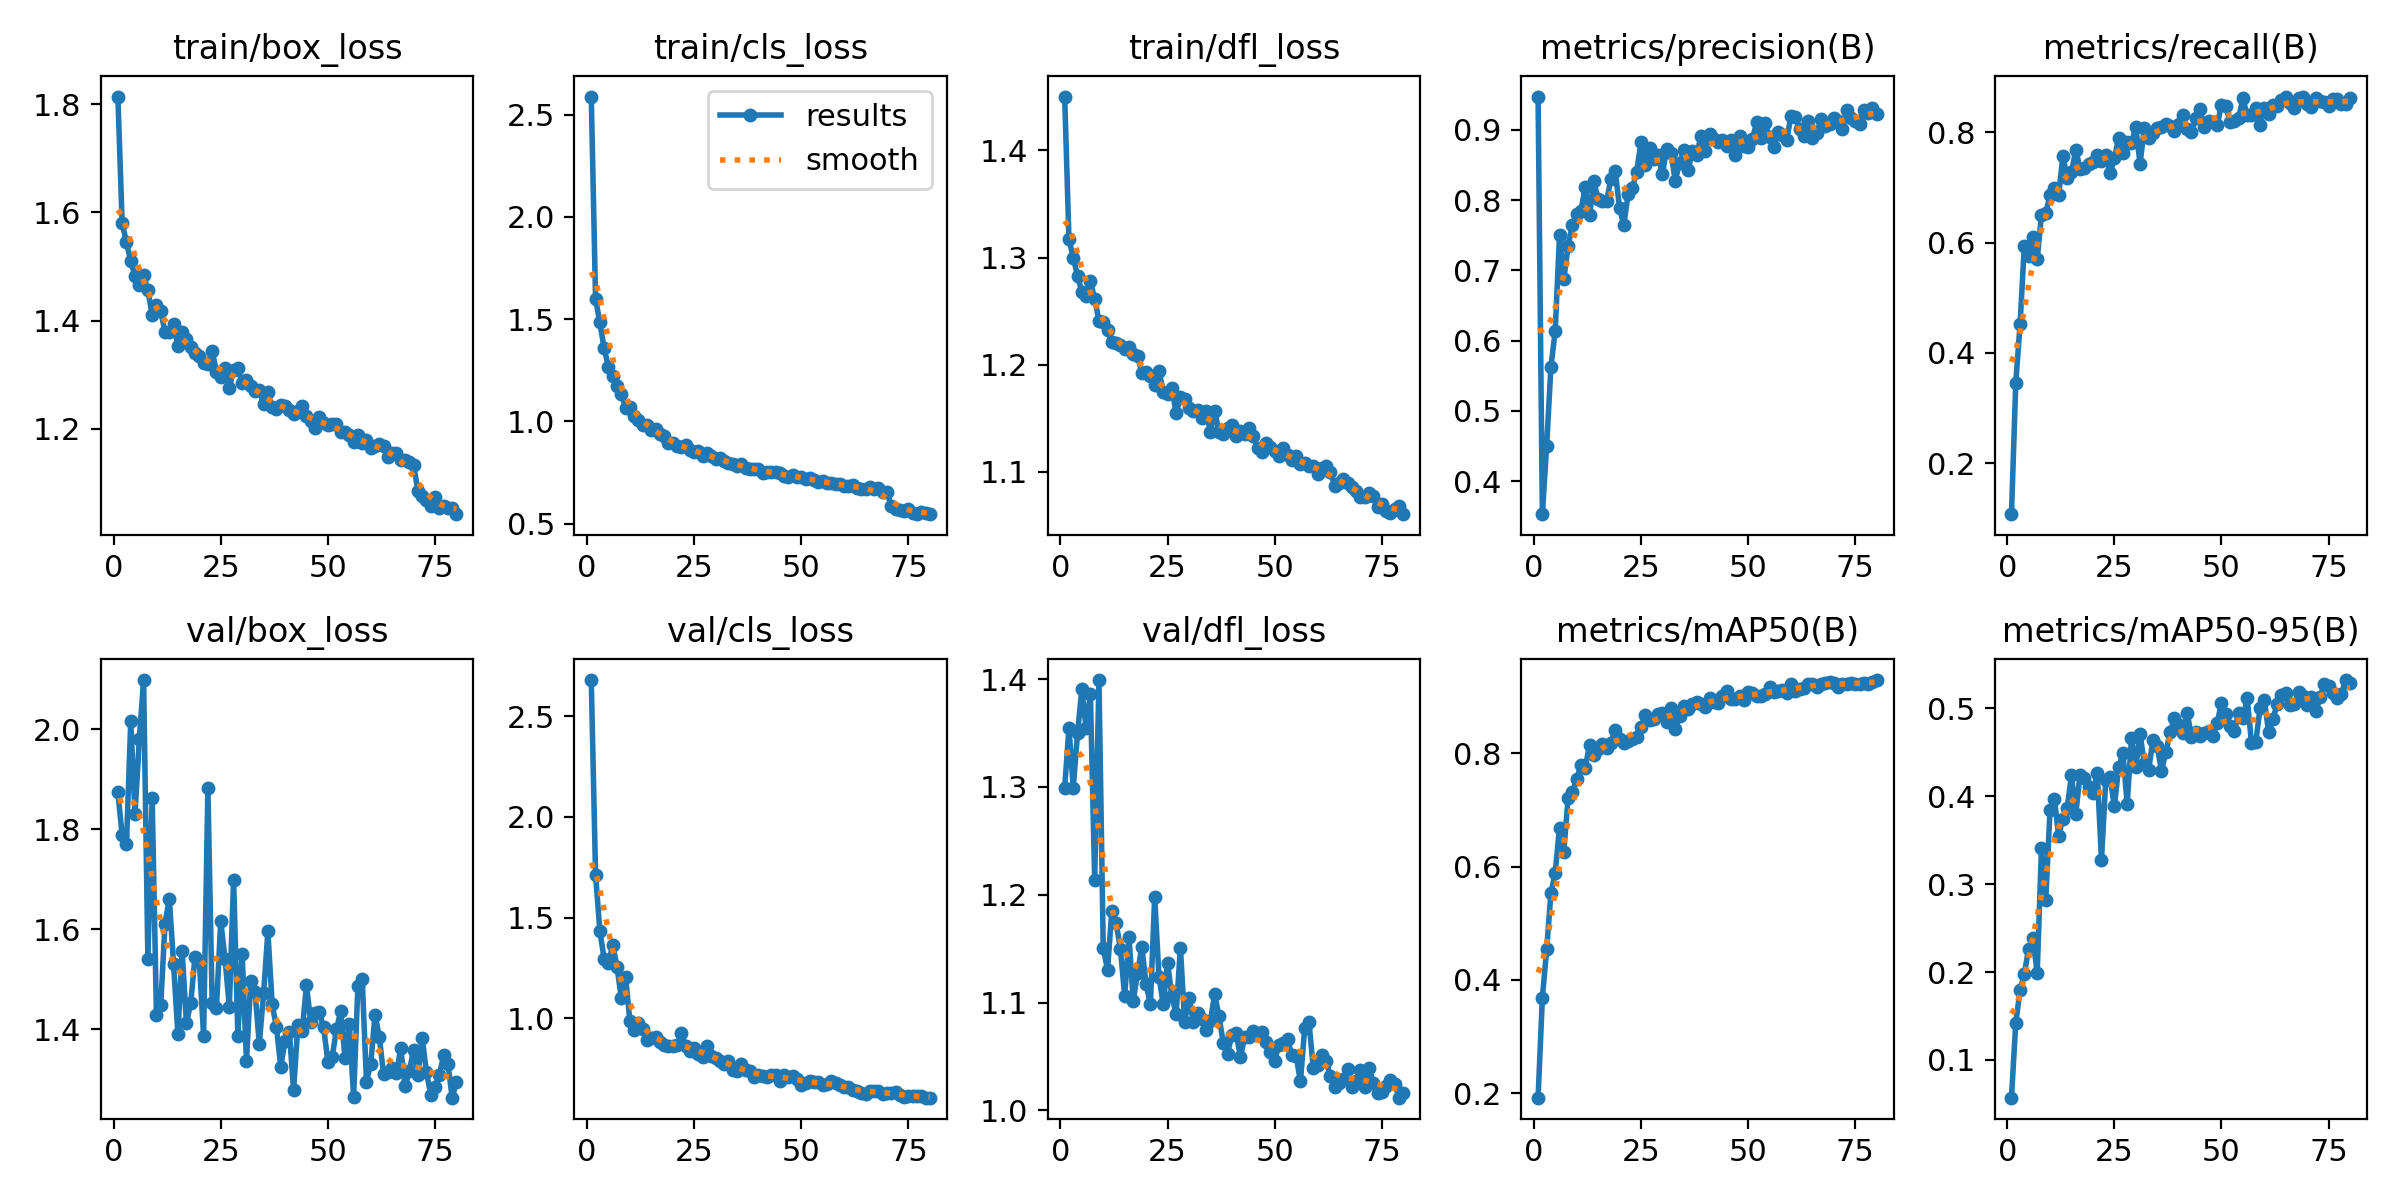

No encontrado: runs/detect/train/PR_curve.png
No encontrado: runs/detect/train/P_curve.png
No encontrado: runs/detect/train/R_curve.png
No encontrado: runs/detect/train/F1_curve.png

Mostrando: confusion_matrix.png


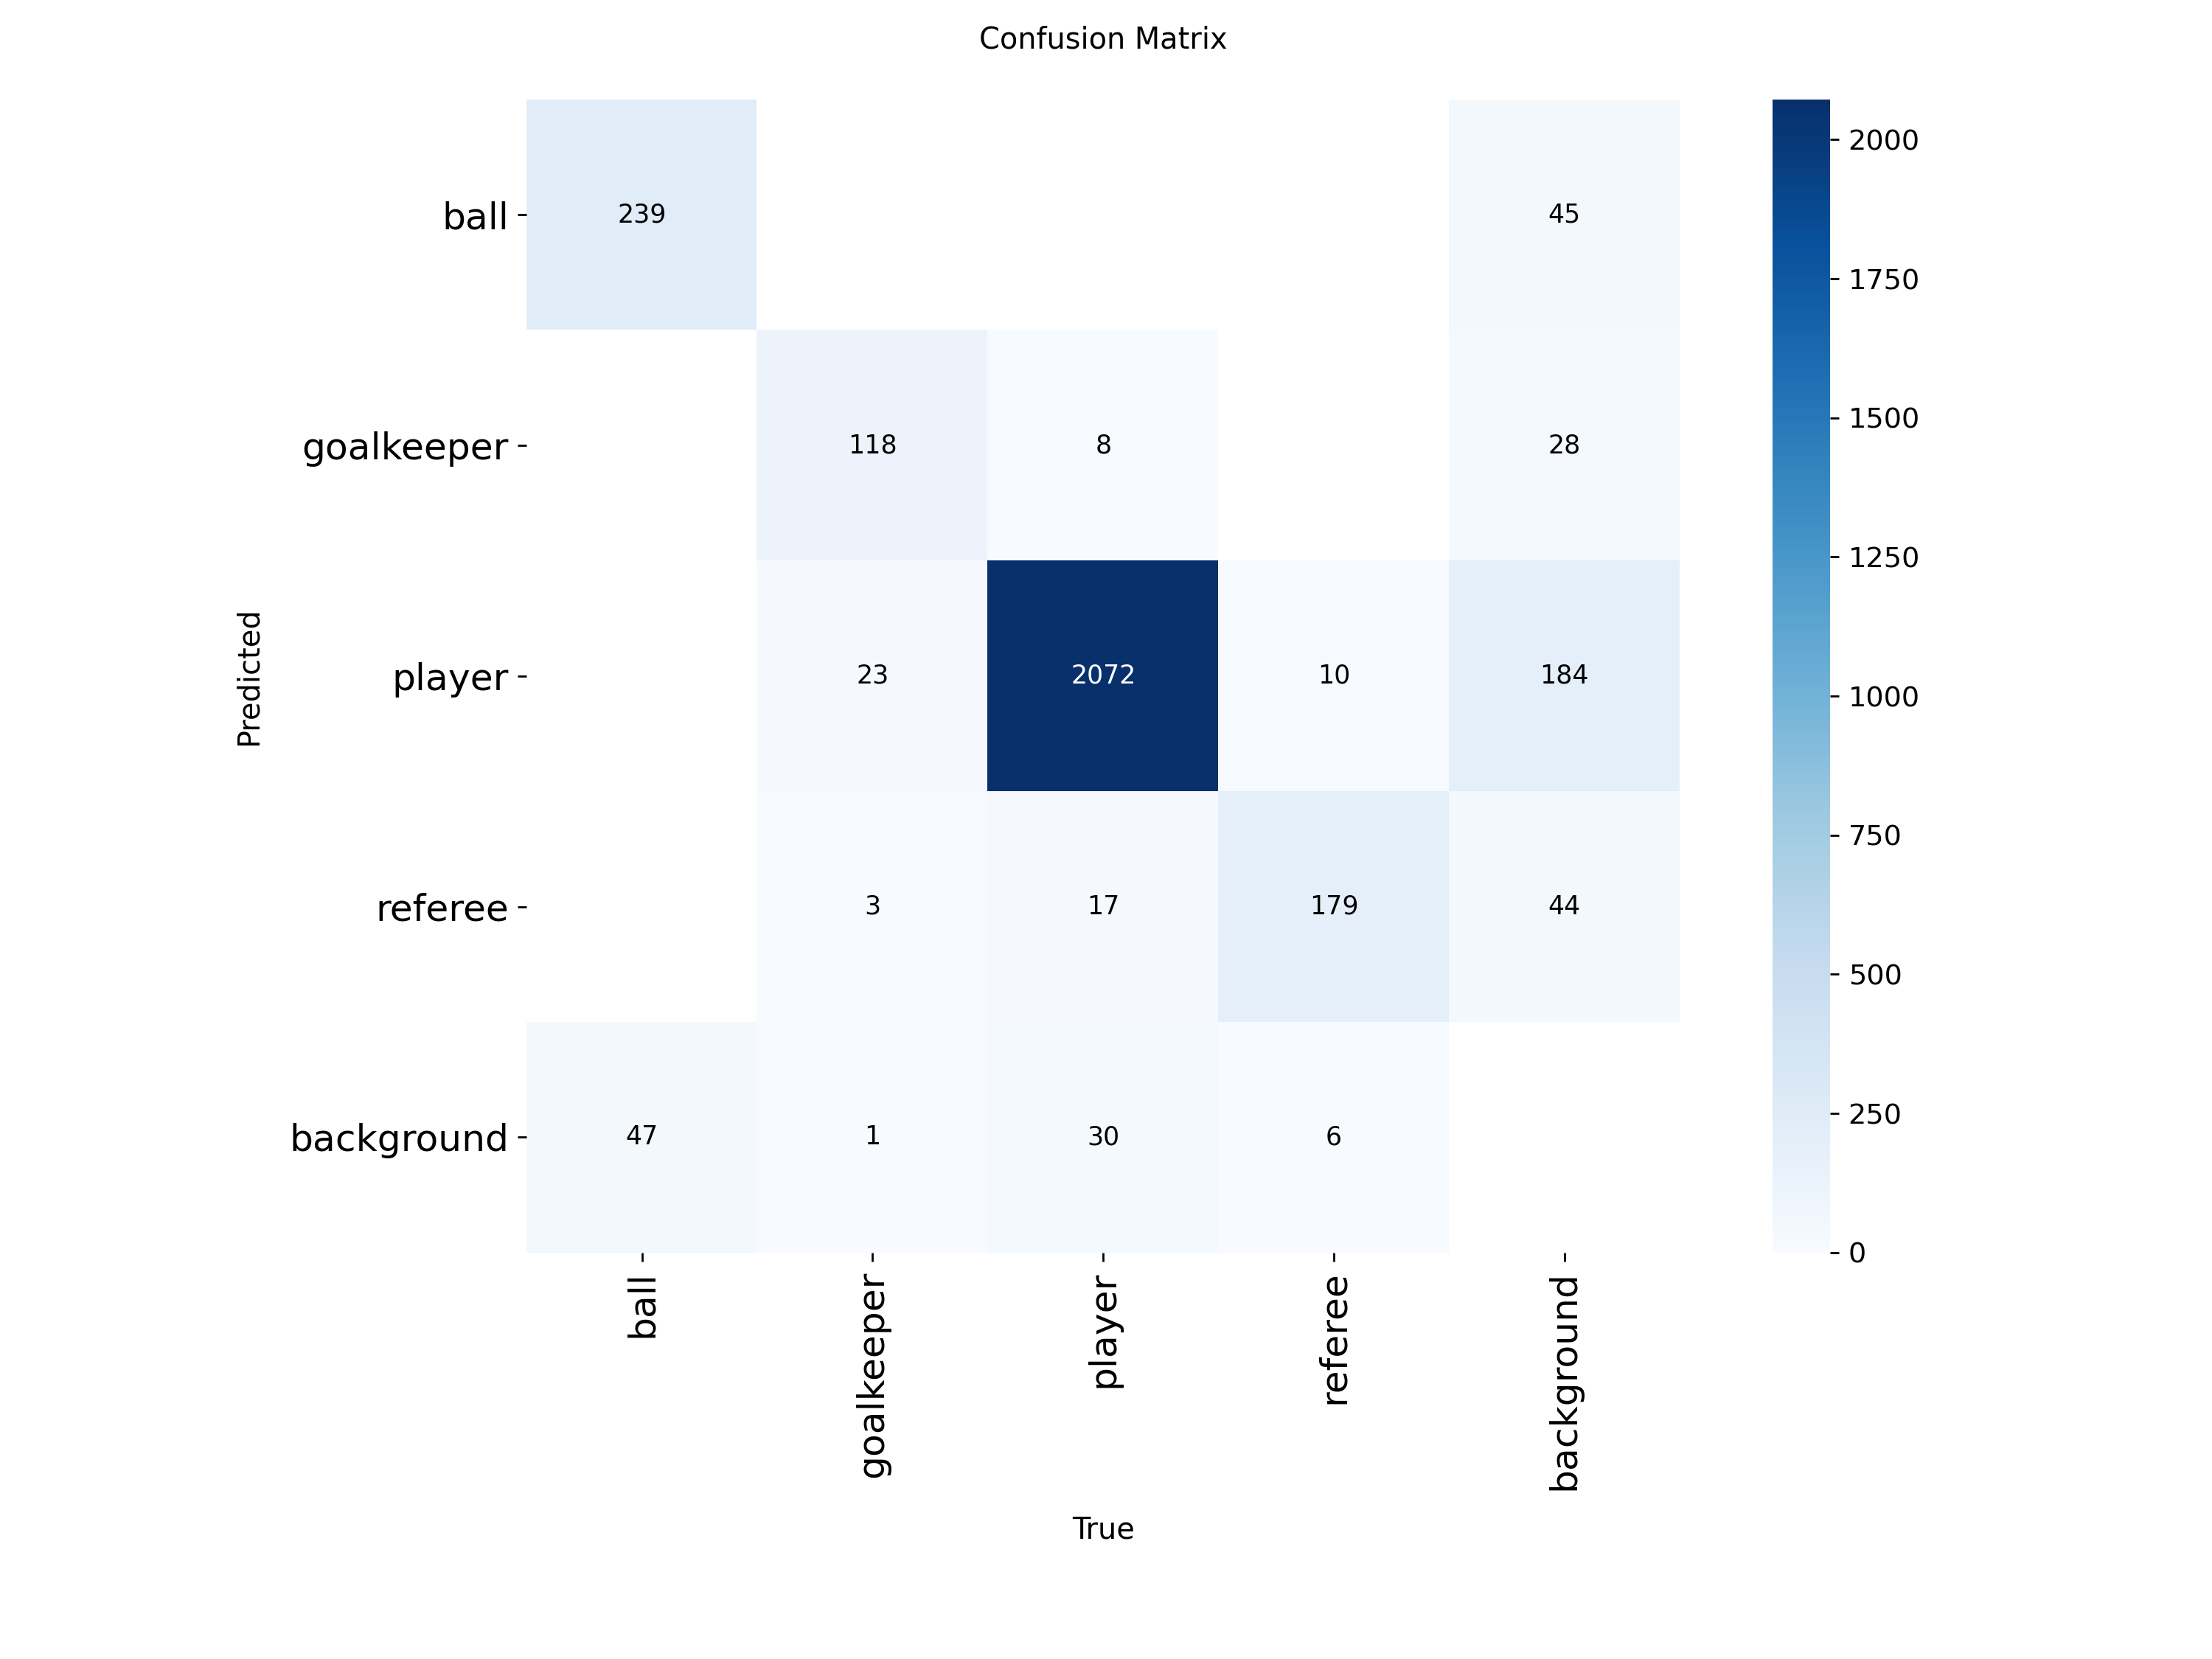


Mostrando: confusion_matrix_normalized.png


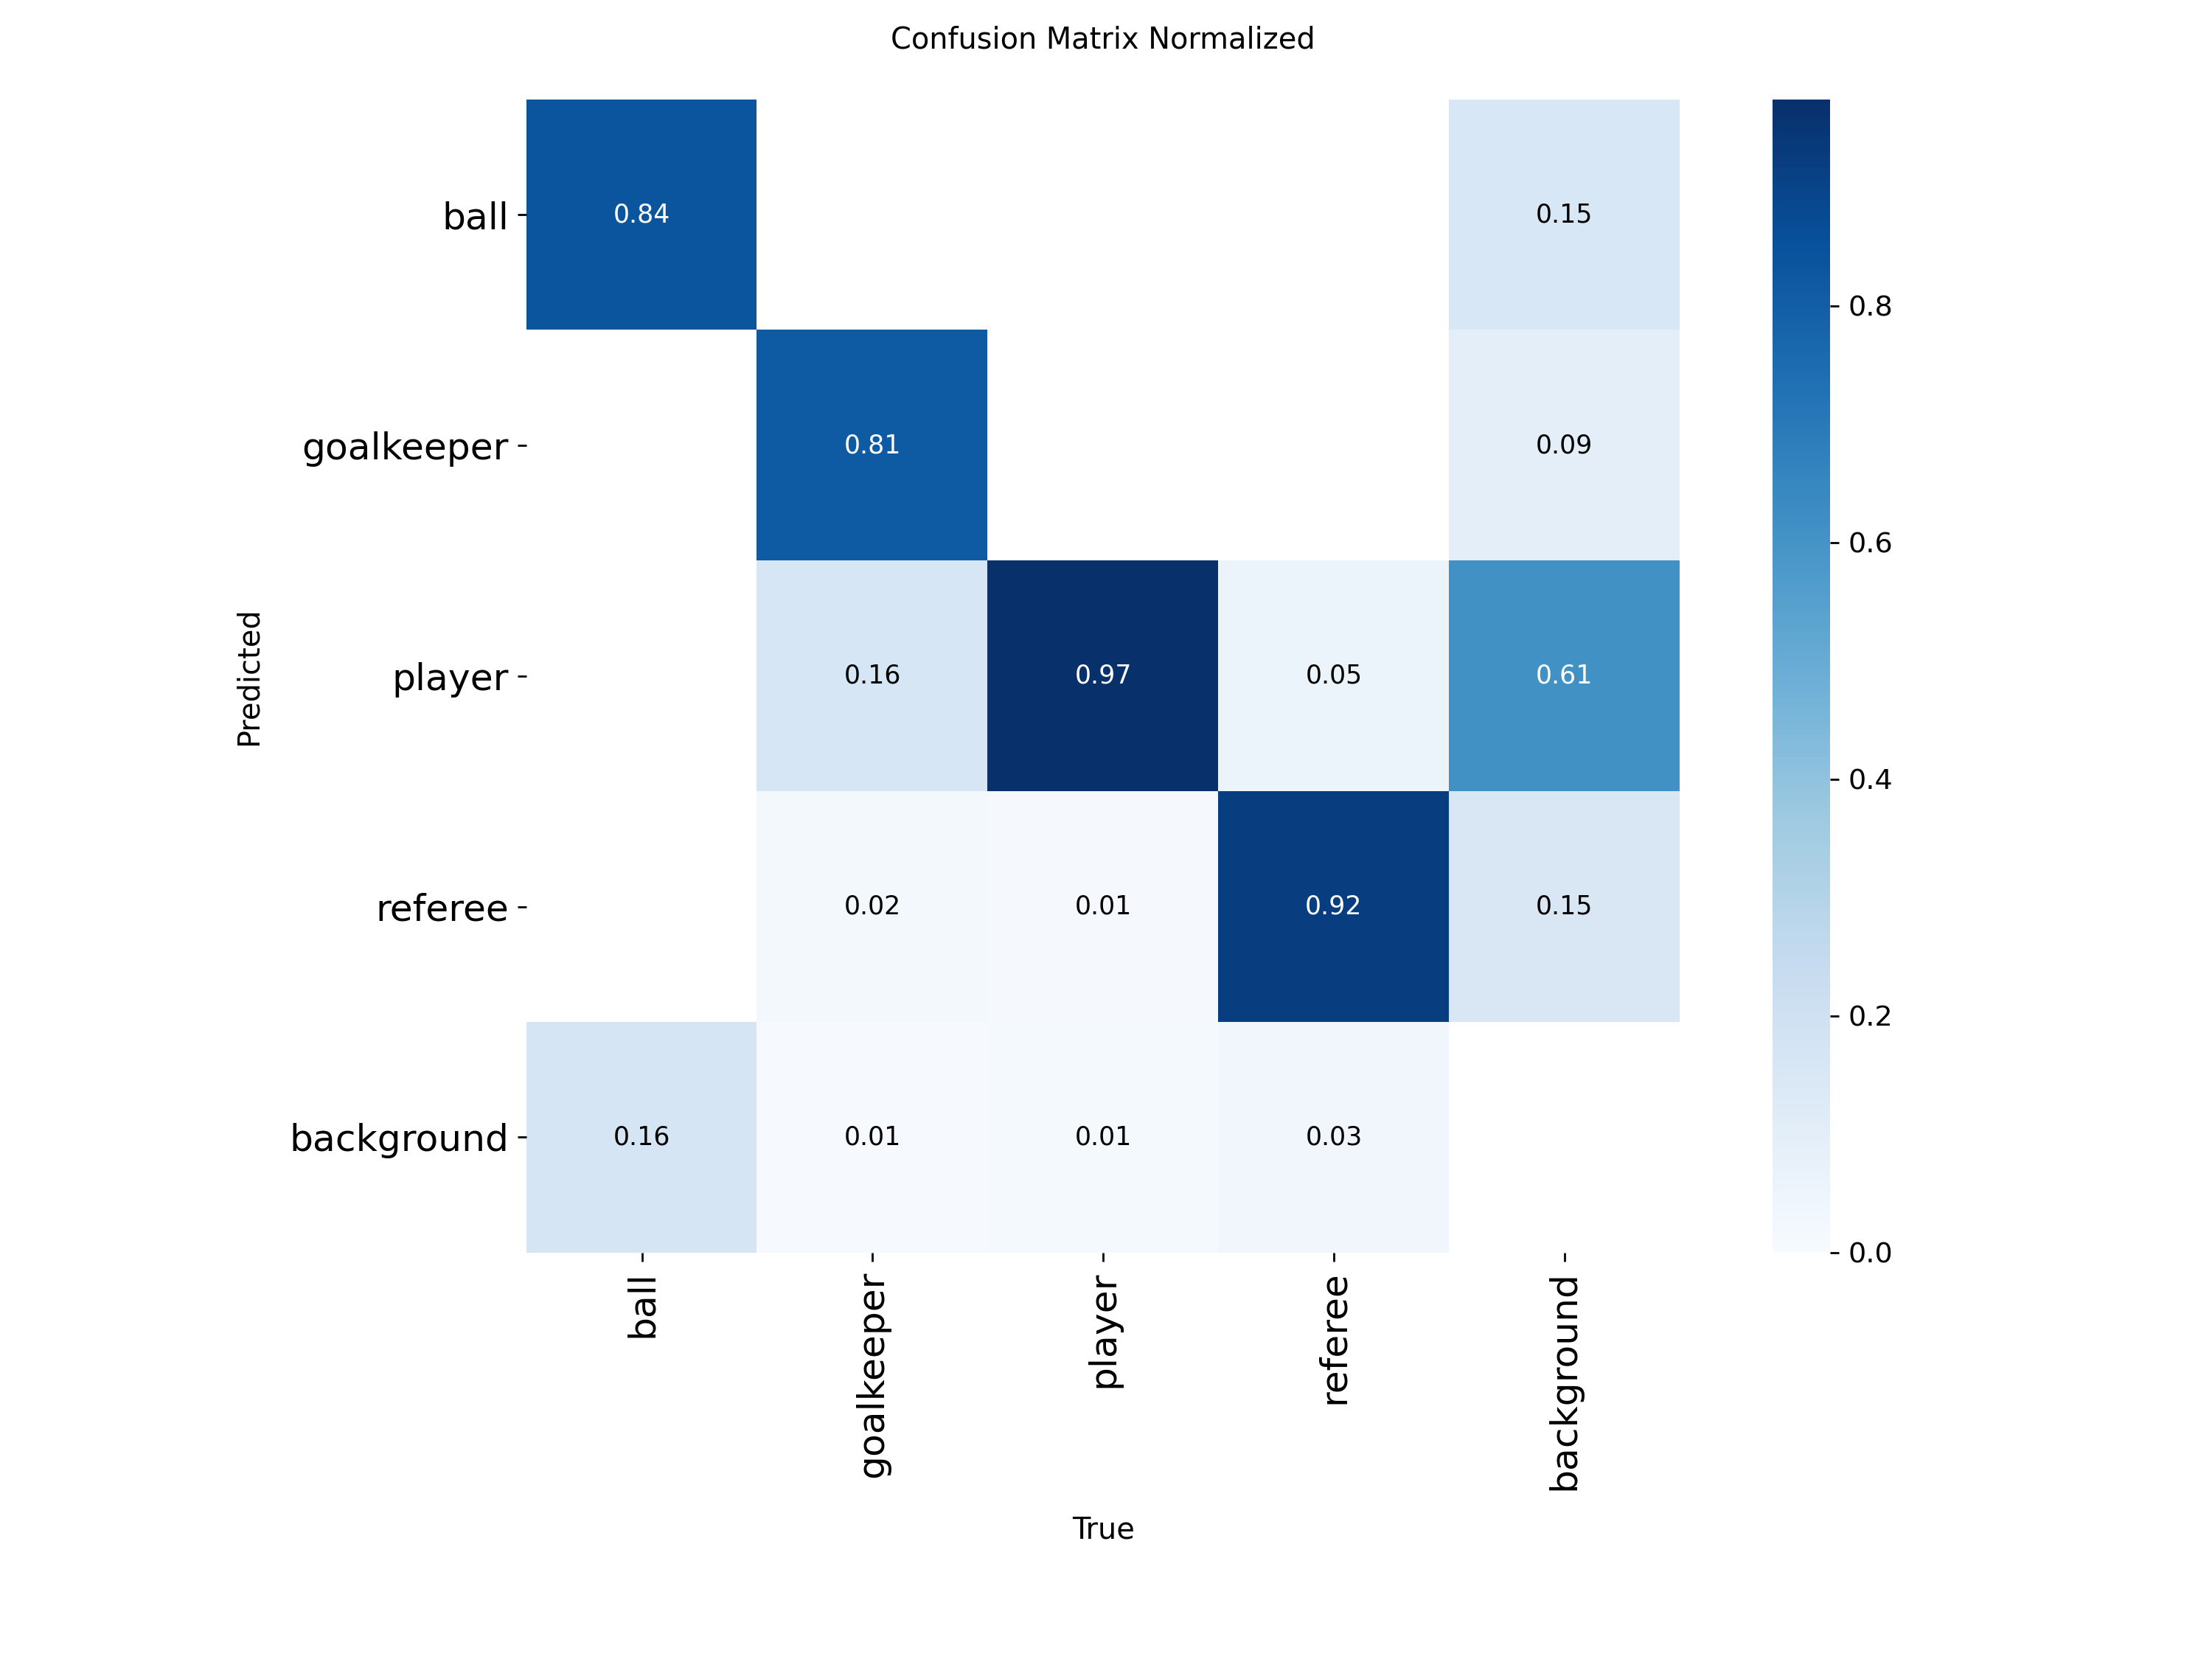

In [ ]:
run_dir = "runs/detect/train"

files_to_show = [
    "results.png",
    "PR_curve.png",
    "P_curve.png",
    "R_curve.png",
    "F1_curve.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
]

for fname in files_to_show:
    fpath = os.path.join(run_dir, fname)
    if os.path.exists(fpath):
        print(f"\nMostrando: {fname}")
        display(Image(filename=fpath))
    else:
        print(f"No encontrado: {fpath}")

In [8]:
model_n.predict(source="gol.mp4", save=True, project="resultados", name="prueba_video", exist_ok=True)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/180) /home/jiteich/repos/ceia/vision_computadora_ii/TP_VpC2/gol.mp4: 320x640 1 goalkeeper, 18 players, 27.4ms
video 1/1 (frame 2/180) /home/jiteich/repos/ceia/vision_computadora_ii/TP_VpC2/gol.mp4: 320x640 1 goalkeeper, 16 players, 2.1ms
video 1/1 (frame 3/180) /home/jiteich/repos/ceia/vision_computadora_ii/TP_VpC2/gol.mp4: 320x640 1 goalkeeper, 15 players, 1.9ms
video 1/1 (frame 4/180) /home/jiteich/repos/ceia/vision_computadora_ii/TP

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'ball', 1: 'goalkeeper', 2: 'player', 3: 'referee'}
 obb: None
 orig_img: array([[[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        ...,
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
         [0, 0, 0],
         [0, 0, 0],
         [0, 0, 0]],
 
        [[0, 0, 0],
         [0, 0, 0],
         [0, 0, 0],
         ...,
 